# Optimización multi-activo con cripto: capítulo 5

## Pronóstico supervisado de riesgo y overlay dinámico

*Capítulo 5 — ¿puede una capa de pronóstico ML mejorar el control de riesgo a la baja, neto de costes, sin sobreajuste?*

---

### Abstract / Pregunta de investigación

Los capítulos 1–4 establecen un baseline de Mínima Varianza (MinVar) con perfil defensivo, uso moderado del *sleeve* cripto y robustez razonable frente a perturbaciones de diseño. Sin embargo, un resultado defensivo estático suscita una pregunta táctica: **¿existe información en el estado de riesgo corriente que permita anticipar periodos de mayor volatilidad o estrés y modular la exposición cripto de forma útil?**

Este capítulo pregunta específicamente:

> **"¿Una capa de pronóstico de riesgo supervisado mejora el control del riesgo a la baja *out-of-sample*, neto de costes, sin sobreajuste?"**

El capítulo no pregunta si el ML genera alfa. No trata de predecir retornos. No construye una narrativa a favor de la criptomoneda como asignación estructural. El objeto de estudio es estrictamente la **capacidad de pronóstico de variables de riesgo** y la **traducción de ese pronóstico a valor económico** medido por Calmar, Expected Shortfall y drawdown máximo, neto de turnover.

### Contexto en la secuencia del trabajo

| Capítulo | Pregunta | Resultado relevante para Ch5 |
|---|---|---|
| 1 | ¿Qué perfil tiene el MinVar restringido? | Defensivo, bajo cripto estructural (~1 %) |
| 2 | ¿Qué sobrevive a perturbaciones de diseño y costes? | Perfil cualitativo estable; diferencias pequeñas |
| 3 | ¿Qué pasa en la cola izquierda? | MaxDD ≈ −23 %; tail risk gestionable pero presente |
| 4 | ¿Qué predicen los regímenes? | Los regímenes tienen valor diagnóstico; señal táctica limitada |
| **5** | **¿ML mejora el control de riesgo tácticamente?** | **Este capítulo** |

### Qué evidencia sería necesaria para afirmar que el overlay aporta valor

1. Los pronósticos mejoran un benchmark naive/EWMA en validación walk-forward.
2. El overlay mejora MaxDD, ES95 o Calmar *neto de costes* frente al MinVar baseline.
3. El overlay mejora al control sin cripto o lo iguala con menor coste de oportunidad.
4. La mejora es reproducible bajo ML *y* bajo reglas naive, no solo bajo ML.

### Qué evidencia **no** es suficiente

- Mejora de métricas de clasificación (AUC) sin mejora económica.
- Curvas de riqueza visualmente similares con diferencias dentro del ruido de estimación.
- Mejora gross que desaparece neto de costes adicionales de *turnover*.
- El modelo ML supera al naive solo en los datos, no en la cartera.


### Tabla de claims y no-claims

| Claim | No-claim |
|---|---|
| Pronosticamos riesgo (volatilidad, probabilidad de estrés), no retornos. | No reclamamos alfa persistente derivado del ML. |
| Evaluamos valor económico, no solo precisión predictiva. | No reclamamos que cripto mejore la cartera estructuralmente. |
| Comparamos ML contra baselines naive y EWMA. | No reclamamos superioridad del ML salvo que supere al naive neto de costes. |
| Las decisiones de overlay son auditables (reason codes persistidos). | No reclamamos que los regímenes sean señales de trading. |
| Se usa validación walk-forward con embargo para evitar leakage. | No eliminamos todo posible overfitting; el diseño lo mitiga, no lo erradica. |
| El análisis distingue valor predictivo de valor económico. | No concluimos que "ML funciona" si solo mejora métricas estadísticas. |

### Qué hace y qué no hace este notebook

| Hace | No hace |
|---|---|
| Carga artefactos precomputados de `outputs/chapter5/`. | Volver a correr el optimizador MinVar. |
| Lee el pronóstico de riesgo en dos niveles: estadístico y económico. | Realizar búsqueda amplia de hiperparámetros. |
| Contrasta cada overlay vs baseline, vs no-cripto y vs regla naive. | Introducir efectivo sintético ni activos no presentes en el baseline. |
| Audita las decisiones del overlay con reason codes. | Reclamar tradability sin datos de mercado en vivo. |
| Reporta turnover y costes adicionales del overlay. | Omitir el coste de complejidad del overlay combinado. |
| Concluye de forma prudente, respaldada por las tablas. | Vender ML si la evidencia económica es débil. |


### Anclas en la literatura

El diseño de Chapter 5 se apoya en cuatro líneas de investigación:

- **Predicción de volatilidad realizada.** Andersen et al. (2003) muestran que la volatilidad realizada es altamente predecible a corto plazo; los modelos HAR (Corsi, 2009) aprovechan la autocorrelación multi-horizonte. Este capítulo utiliza ese principio para justificar por qué *rolling vol* y EWMA son benchmarks difíciles de batir: la persistencia de la volatilidad hace que el modelo naive sea competitivo. Superar al naive requiere información adicional, no solo mayor complejidad.

- **Señales de crisis y clasificación de estrés.** Acharya et al. (2017) y Giglio et al. (2016) documentan que las medidas de riesgo sistémico tienen contenido predictivo sobre eventos extremos futuros. La clasificación de eventos de estrés en este capítulo no replica esos índices pero sigue el mismo principio: usar el estado del mercado corriente para anticipar periodos de mayor tensión.

- **ML para pronóstico financiero: benchmark naive como listón.** Makridakis et al. (2018) documentan sistemáticamente que los métodos simples son difíciles de batir en pronóstico de series temporales. En finanzas, Harvey et al. (2016) insisten en que los *t-stats* del ML deben ajustarse por *multiple testing*. Este capítulo adopta un enfoque conservador: el ML se selecciona solo si supera al naive en validación walk-forward; si no, se usa el naive.

- **Overlay dinámico y *risk budgeting*.** Roncalli (2013) y Bruder y Roncalli (2012) formalizan el *risk parity* y el *risk budgeting*. El overlay de este capítulo no aplica *risk parity* pero comparte el principio: las decisiones de asignación se condicionan sobre el estado de riesgo estimado, no sobre pronósticos de retorno.

Estas anclas justifican el diseño pero no garantizan los resultados. La evidencia es la que determina si el overlay aporta valor en esta muestra.


### Cómo leer este notebook

El capítulo apila tres tipos de evidencia que conviene no confundir:

1. **Evidencia predictiva OOS.** Tablas de RMSE, R² OOS, ROC-AUC y PR-AUC por modelo y target, en validación walk-forward. Responde a *¿los modelos aprenden algo útil?*

2. **Evidencia económica / operativa.** Comparación de Sharpe, Calmar, MaxDD, ES95 y turnover entre estrategias de overlay y controles. Responde a *¿ese aprendizaje se traduce en valor para el portfolio?*

3. **Auditoría de decisiones.** Reason codes por periodo, impacto en peso cripto realizado, activaciones del cap dinámico. Responde a *¿el overlay realmente cambia algo en la asignación?*

Dos reglas de lectura aplican siempre:

- Un modelo puede tener buen AUC y no mejorar la cartera. La evaluación económica es la lectura vinculante, no las métricas ML.
- Un overlay puede ser formalmente correcto y ser **no-binding**: si el motor MinVar ya controla la exposición cripto por optimización, el cap dinámico no añade nada. Esa posibilidad es considerada explícitamente.

---


In [79]:
from __future__ import annotations

import json
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ── Paths ─────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OUT = PROJECT_ROOT / "outputs" / "chapter5"

# ── Style (consistent with Notebooks 02–04) ───────────────────────────────────
STYLE = {
    "baseline":   "#1f77b4",
    "no_crypto":  "#d62728",
    "naive_vol":  "#2ca02c",
    "ml_vol":     "#9467bd",
    "stress":     "#ff7f0e",
    "combined":   "#8c564b",
    "accent":     "#17becf",
    "warn":       "#e377c2",
    "gray":       "#bfc4cc",
}

DISPLAY_NAMES = {
    "minvar_baseline_corrected":                   "MinVar Baseline",
    "minvar_no_crypto_control":                    "MinVar sin cripto",
    "minvar_dynamic_crypto_cap_naive_vol":         "Overlay Vol Naive",
    "minvar_dynamic_crypto_cap_ml_vol":            "Overlay Vol ML",
    "minvar_dynamic_crypto_cap_stress_probability": "Overlay Stress-Prob",
    "minvar_combined_overlay":                     "Overlay Combinado",
}

STRATEGY_ORDER = list(DISPLAY_NAMES.keys())

COLORS = {
    "minvar_baseline_corrected":                   STYLE["baseline"],
    "minvar_no_crypto_control":                    STYLE["no_crypto"],
    "minvar_dynamic_crypto_cap_naive_vol":         STYLE["naive_vol"],
    "minvar_dynamic_crypto_cap_ml_vol":            STYLE["ml_vol"],
    "minvar_dynamic_crypto_cap_stress_probability": STYLE["stress"],
    "minvar_combined_overlay":                     STYLE["combined"],
}

# ── Load data ─────────────────────────────────────────────────────────────────
model_scores   = pd.read_csv(OUT / "model_scores.csv")   if (OUT / "model_scores.csv").exists()   else pd.DataFrame()
model_selection = pd.read_csv(OUT / "model_selection.csv") if (OUT / "model_selection.csv").exists() else pd.DataFrame()
summary        = pd.read_csv(OUT / "overlay_backtest_summary.csv") if (OUT / "overlay_backtest_summary.csv").exists() else pd.DataFrame()
decisions      = pd.read_csv(OUT / "overlay_decisions.csv")        if (OUT / "overlay_decisions.csv").exists()        else pd.DataFrame()
daily          = pd.read_csv(OUT / "overlay_daily_returns.csv", parse_dates=["date"]) if (OUT / "overlay_daily_returns.csv").exists() else pd.DataFrame()
turnover_df    = pd.read_csv(OUT / "overlay_turnover.csv")          if (OUT / "overlay_turnover.csv").exists()          else pd.DataFrame()

with open(OUT / "chapter5_metadata.json") as f:
    meta = json.load(f)

# ── Helper: formatted metric table ────────────────────────────────────────────
def pct(s, decimals=2):
    return s.map(lambda v: f"{v*100:.{decimals}f}%" if pd.notna(v) else "—")

def fmt(s, decimals=4):
    return s.map(lambda v: f"{v:.{decimals}f}" if pd.notna(v) else "—")

print(f"✓ model_scores:    {len(model_scores)} rows, {model_scores['target_col'].nunique() if not model_scores.empty else 0} targets")
print(f"✓ model_selection: {len(model_selection)} rows")
print(f"✓ overlay summary: {len(summary)} strategies")
print(f"✓ overlay decisions: {len(decisions)} rows")
print(f"✓ daily returns:   {len(daily)} rows")
print(f"✓ turnover:        {len(turnover_df)} rows")
print(f"✓ metadata loaded — run_timestamp: {meta.get('run_timestamp_utc','?')[:19]}")


✓ model_scores:    55 rows, 12 targets
✓ model_selection: 12 rows
✓ overlay summary: 6 strategies
✓ overlay decisions: 534 rows
✓ daily returns:   11484 rows
✓ turnover:        534 rows
✓ metadata loaded — run_timestamp: 2026-05-03T14:53:49


---
## 1 — Herencia metodológica de los capítulos 1–4

Chapter 5 no parte de cero. Hereda explícitamente las decisiones de diseño validadas en los capítulos anteriores. Cambiar alguna de ellas introduciría un grado de libertad adicional sin respaldo empírico en este análisis.

| Decisión metodológica | Por qué importa | Implicación en Ch5 |
|---|---|---|
| Calendario alineado a días hábiles | Evita retornos ETF de fin de semana artificiales | Los features y targets usan la misma serie corregida |
| Retornos *drifted buy-and-hold* (mensual) | Ruta realista de tenencias entre rebalanceos | El overlay se evalúa sobre el mismo motor de backtest |
| Factor de anualización 252 (días hábiles) | Coherencia con el resto del proyecto | Volatilidades y métricas son comparables entre capítulos |
| Control sin cripto (`minvar_no_crypto_control`) | Aísla la contribución del *sleeve* cripto | El overlay debe superar este control para "justificar" la exposición cripto |
| Tope de costes vía turnover one-way | Fricción realista; costes escalables con actividad | Las estrategias de overlay pagan más si activan más rebalanceos |
| Benchmarks simétricos (drifted) | Evita comparaciones sesgadas por mecánica distinta | Todos los benchmarks usan la misma mecánica |
| Regímenes como diagnóstico, no como señal | Las etiquetas de régimen tienen incertidumbre ex-ante | Si se usan como features, se trata como información del estado pasado, no como verdad futura |
| Validación estrictamente OOS | Evitar contaminación in-sample | Walk-forward con embargo; ningún resultado se lee en muestra de entrenamiento |

**Lectura.** La lista anterior no es decorativa. Cada fila representa una decisión que podría haberse tomado de otro modo y que afectaría la comparabilidad de resultados. Al fijarlas, Chapter 5 pregunta únicamente si *añadir una capa de señal de riesgo* mejora el portfolio, manteniendo todo lo demás constante.


---
## 2 — Qué contrasta Chapter 5

Antes de mostrar números, conviene ser explícito sobre qué pregunta responde cada test. La siguiente tabla previene lecturas que mezclen preguntas distintas.

| Test | Pregunta económica | Evidencia requerida para afirmar "funciona" |
|---|---|---|
| Pronóstico de volatilidad de cartera | ¿Podemos anticipar el riesgo a corto plazo del portfolio? | RMSE/R² OOS mejora al naive rolling-vol y EWMA |
| Pronóstico de volatilidad de activos (SPY, BTC) | ¿Podemos anticipar el riesgo de los activos subyacentes? | Mismo criterio; relevante para informar el cap dinámico |
| Clasificación de eventos de drawdown (21d / 63d) | ¿Podemos detectar periodos previos a drawdowns materiales? | ROC-AUC y PR-AUC útiles; recall suficiente en clase positiva |
| Clasificación de estrés (stress_event_21d) | ¿Existe una señal combinada de estrés sistémico anticipable? | PR-AUC material, calibración razonable |
| Overlay de volatilidad naive vs ML | ¿El ML añade algo sobre la regla de vol naive? | MinVar-ML supera a MinVar-naive neto de costes |
| Overlay de probabilidad de estrés | ¿La señal de estrés reduce MaxDD/ES sin dañar Calmar? | Mejora en MaxDD y/o ES sin aumentar costes proporcionalmente |
| Overlay combinado | ¿Combinar vol + estrés añade valor sobre cada señal sola? | Mejora marginal sobre los overlays individuales, no solo complejidad |
| Control sin cripto | ¿El overlay supera a simplemente no tener cripto? | Overlay ≥ no-cripto en Sharpe, Calmar y ES95 |

**Lectura.** La tabla estructura los contrastes antes de ver los datos. Responder "sí" o "no" a cada fila con honestidad es el objetivo del capítulo, no demostrar que "ML funciona".


---
## 3 — Construcción de targets

Los targets se construyen con información estrictamente posterior al instante $t$: el target en $t$ usa retornos de $t+1$ hasta $t+h$, nunca información de $t$ en adelante más allá del horizonte. Las últimas $h$ observaciones quedan en NaN por diseño. Esta regla es el control anti-leakage más importante del capítulo.

### Targets de regresión (volatilidad y drawdown)

$$
\text{vol\_fwd}_{t,h} = \sqrt{252} \cdot \text{std}(r_{t+1}, \ldots, r_{t+h})
$$

$$
\text{dd\_fwd}_{t,h} = \min_{k \in [t+1, t+h]} \frac{V_{t+k} - \max_{j \leq t+k} V_j}{\max_{j \leq t+k} V_j}
$$

donde $V_t$ es el nivel acumulado de la cartera (o del activo).

### Targets de clasificación (eventos de estrés y drawdown)

$$
\text{dd\_event}_{t,h} = \mathbf{1}\left[\text{dd\_fwd}_{t,h} < \theta_{h}\right]
$$

$$
\text{stress\_event}_{t} = \mathbf{1}\left[\text{retorno\_fwd}_{t,21d} \leq Q_{0.10}\right]
$$

donde $\theta_{h}$ es un umbral de pérdida calibrado por horizonte y activo (portfolio 21d: −5 %, portfolio 63d: −10 %, BTC 21d: −15 %, BTC 63d: −25 %) y $Q_{0.10}$ es el percentil 10 de la distribución de retornos forward a 21 días.

### Tabla de cobertura de targets


In [80]:
# ── §3 Target coverage: tabla de cobertura ────────────────────────────────────
if not model_scores.empty:
    reg_targets  = ["target_portfolio_vol_21d", "target_portfolio_vol_63d",
                    "target_spy_vol_21d", "target_spy_vol_63d",
                    "target_btc_vol_21d", "target_btc_vol_63d",
                    "target_portfolio_dd_21d", "target_portfolio_dd_63d"]
    cls_targets_cov = ["target_portfolio_dd_event_21d", "target_portfolio_dd_event_63d",
                       "target_btc_dd_event_21d", "target_stress_event_21d"]

    target_labels_cov = {
        "target_portfolio_vol_21d":    "Vol cartera 21d",
        "target_portfolio_vol_63d":    "Vol cartera 63d",
        "target_spy_vol_21d":          "Vol SPY 21d",
        "target_spy_vol_63d":          "Vol SPY 63d",
        "target_btc_vol_21d":          "Vol BTC 21d",
        "target_btc_vol_63d":          "Vol BTC 63d",
        "target_portfolio_dd_21d":     "Drawdown cartera 21d",
        "target_portfolio_dd_63d":     "Drawdown cartera 63d",
        "target_portfolio_dd_event_21d": "Evento DD cartera 21d",
        "target_portfolio_dd_event_63d": "Evento DD cartera 63d",
        "target_btc_dd_event_21d":     "Evento DD BTC 21d",
        "target_stress_event_21d":     "Evento de estrés 21d",
    }
    thresholds_cov = {
        "target_portfolio_dd_event_21d": "−5 %",
        "target_portfolio_dd_event_63d": "−10 %",
        "target_btc_dd_event_21d":       "−15 %",
        "target_stress_event_21d":       "p10 fwd-ret",
    }
    task_map = {t: "regresión"     for t in reg_targets}
    task_map.update({t: "clasificación" for t in cls_targets_cov})

    coverage_rows = []
    for tc in reg_targets + cls_targets_cov:
        sub = model_scores[model_scores["target_col"] == tc]
        n_models = len(sub)
        coverage_rows.append({
            "Target":             target_labels_cov.get(tc, tc),
            "Tarea":              task_map.get(tc, "?"),
            "Modelos eval.":      n_models,
            "Umbral / def.":      thresholds_cov.get(tc, "—"),
            "Horizonte":          "21d" if "21d" in tc else "63d",
        })

    coverage_df = pd.DataFrame(coverage_rows).set_index("Target")
    print("── Tabla de cobertura de targets ────────────────────────────────────────────")
    display(coverage_df)


── Tabla de cobertura de targets ────────────────────────────────────────────


,Tarea,Modelos eval.,Umbral / def.,Horizonte
Target,,,,
Vol cartera 21d,regresión,5,—,21d
Vol cartera 63d,regresión,5,—,63d
Vol SPY 21d,regresión,5,—,21d
Vol SPY 63d,regresión,5,—,63d
Vol BTC 21d,regresión,5,—,21d
Vol BTC 63d,regresión,5,—,63d
Drawdown cartera 21d,regresión,5,—,21d
Drawdown cartera 63d,regresión,5,—,63d
Evento DD cartera 21d,clasificación,4,−5 %,21d


**Lectura.** Se evalúan 12 targets en total: 8 de regresión (vol y drawdown continuo) y 4 de clasificación (eventos binarios de estrés o drawdown severo). Para los targets de clasificación, el número de eventos positivos es potencialmente bajo —especialmente en horizontes 21d— lo que hace que la PR-AUC sea más informativa que la accuracy o incluso la ROC-AUC. El umbral del stress event (percentil 10 del retorno forward) garantiza una tasa de eventos positivos ≈ 10 %, lo que es manejable para clasificación aunque sigue siendo imbalanced.

**Límite inferencial.** La muestra OOS disponible es limitada (~89 rebalanceos mensuales). Cualquier métrica de clasificación calculada sobre esta muestra tiene una varianza de estimación no despreciable. Los AUC puntuales deben leerse con cautela, no como estimaciones precisas.


In [81]:
# ── §4 Feature set: tabla descriptiva de bloques ──────────────────────────────
feature_blocks = pd.DataFrame([
    {
        "Bloque":              "Riesgo de cartera",
        "Ejemplos":            "rolling_vol_21d/63d/126d, rolling_return_21d, rolling_drawdown_21d",
        "Intuición económica": "Estado de riesgo reciente del portfolio; la vol persiste",
        "Control leakage":     "Solo información hasta t; no se usa vol realizada de t+1",
    },
    {
        "Bloque":              "Riesgo TradFi",
        "Ejemplos":            "spy_vol_21d/63d, tlt_vol_21d, gld_vol_21d",
        "Intuición económica": "El riesgo de renta variable y bonos anticipa entornos de estrés sistémico",
        "Control leakage":     "Rolling sobre datos hasta t",
    },
    {
        "Bloque":              "Riesgo cripto",
        "Ejemplos":            "btc_vol_21d/63d, eth_vol_21d, btc_momentum_21d",
        "Intuición económica": "La volatilidad cripto es un indicador de riesgo específico del sleeve",
        "Control leakage":     "Rolling sobre datos hasta t; no se usa retorno futuro de BTC",
    },
    {
        "Bloque":              "Correlaciones cross-asset",
        "Ejemplos":            "corr_SPY_TLT_63d, corr_SPY_BTC_63d, corr_BTC_ETH_63d",
        "Intuición económica": "Roturas de diversificación (corr acciones-bonos subiendo) señalan estrés",
        "Control leakage":     "Rolling 63d sobre datos hasta t",
    },
    {
        "Bloque":              "Diagnóstico de régimen",
        "Ejemplos":            "regime_label, regime_bull_prob, regime_bear_prob",
        "Intuición económica": "El estado de régimen (identificado con datos hasta t) resume info macro",
        "Control leakage":     "Etiqueta histórica, no pronóstico; riesgo: etiqueta no observable en tiempo real",
    },
    {
        "Bloque":              "Features de calendario",
        "Ejemplos":            "month_sin, month_cos, quarter",
        "Intuición económica": "Estacionalidad de la volatilidad (enero, Q4); señal débil pero ortogonal",
        "Control leakage":     "Fechas disponibles de forma exacta en t",
    },
])

display(feature_blocks.set_index("Bloque"))

print("\nNota: Las features son variables de estado de riesgo, no señales de alpha.")
print("No se usan retornos futuros. Las etiquetas de régimen son diagnóstico histórico.")


,Ejemplos,Intuición económica,Control leakage
Bloque,,,
Riesgo de cartera,"rolling_vol_21d/63d/126d, rolling_return_21d, ...",Estado de riesgo reciente del portfolio; la vo...,Solo información hasta t; no se usa vol realiz...
Riesgo TradFi,"spy_vol_21d/63d, tlt_vol_21d, gld_vol_21d",El riesgo de renta variable y bonos anticipa e...,Rolling sobre datos hasta t
Riesgo cripto,"btc_vol_21d/63d, eth_vol_21d, btc_momentum_21d",La volatilidad cripto es un indicador de riesg...,Rolling sobre datos hasta t; no se usa retorno...
Correlaciones cross-asset,"corr_SPY_TLT_63d, corr_SPY_BTC_63d, corr_BTC_E...",Roturas de diversificación (corr acciones-bono...,Rolling 63d sobre datos hasta t
Diagnóstico de régimen,"regime_label, regime_bull_prob, regime_bear_prob",El estado de régimen (identificado con datos h...,"Etiqueta histórica, no pronóstico; riesgo: eti..."
Features de calendario,"month_sin, month_cos, quarter","Estacionalidad de la volatilidad (enero, Q4); ...",Fechas disponibles de forma exacta en t



Nota: Las features son variables de estado de riesgo, no señales de alpha.
No se usan retornos futuros. Las etiquetas de régimen son diagnóstico histórico.


**Lectura del bloque de features.** El diseño de features sigue el principio de *risk state conditioning*: todas las variables capturan el estado de riesgo corriente o pasado, no señales de retorno futuro. El bloque más delicado metodológicamente es el de **diagnóstico de régimen**: aunque las etiquetas se construyen sobre datos pasados, en la práctica un gestor no conocería la etiqueta de régimen en tiempo real con la misma precisión con que se estima ex-post. Este capítulo lo trata como un feature informativo, no como verdad; la evaluación walk-forward absorbe parte de ese riesgo de look-ahead, pero no lo elimina del todo.

---
## 5 — Diseño de validación walk-forward

La validación walk-forward es la única forma correcta de evaluar pronósticos de series temporales sin contaminación de datos futuros. En Cross-Validation estándar, la aleatorización mezcla pasado y futuro; en walk-forward, el conjunto de test siempre es posterior al de entrenamiento.

El **embargo** elimina el solapamiento entre el borde de entrenamiento y el test: dado que los targets se construyen con ventanas de $h$ días, sin embargo las observaciones del borde ya "conocen" la etiqueta de las primeras observaciones de test.

| Parámetro de validación | Valor | Justificación |
|---|---|---|
| `train_window` | 756 días (~3 años) | Suficiente historia para patrones de volatilidad y régimen |
| `test_window` | 63 días (~1 trimestre) | Pronóstico de un trimestre por split |
| `step_size` | 21 días (~1 mes) | Recalibración mensual, coherente con el motor de backtest |
| `embargo` | 21 días | Previene leakage en el borde train/test para targets de horizonte 21d |
| `min_train_size` | 504 días (~2 años) | Tamaño mínimo para estimación estable |
| `random_state` | 42 | Determinista / reproducible |


In [82]:
# ── §5 Walk-forward: parámetros y cobertura ────────────────────────────────────
val = meta.get("validation", {})
fc  = meta.get("forecast_coverage", {})

wf_params = pd.DataFrame([
    {"Parámetro":          "train_window (días)",   "Valor": val.get("train_window", "?"),   "Equivalente": "~3 años hábiles"},
    {"Parámetro":          "test_window (días)",    "Valor": val.get("test_window", "?"),    "Equivalente": "~1 trimestre"},
    {"Parámetro":          "step_size (días)",      "Valor": val.get("step_size", "?"),      "Equivalente": "~1 mes"},
    {"Parámetro":          "embargo (días)",        "Valor": val.get("embargo_days", "?"),   "Equivalente": "= horizonte target 21d"},
    {"Parámetro":          "min_train_size (días)", "Valor": val.get("min_train_size", "?"), "Equivalente": "~2 años hábiles"},
    {"Parámetro":          "random_state",          "Valor": val.get("random_state", "?"),   "Equivalente": "determinista"},
])

cov_params = pd.DataFrame([
    {"Cobertura":   "Fechas de rebalanceo totales",        "Valor": fc.get("n_rebalance_dates", "?")},
    {"Cobertura":   "Observaciones de pronóstico (filas)", "Valor": fc.get("n_forecast_rows", "?")},
    {"Cobertura":   "Rebalanceos con pronóstico disponible","Valor": fc.get("n_rebalance_with_forecast", "?")},
])

print("── Parámetros walk-forward ──────────────────────────────────────────────")
display(wf_params.set_index("Parámetro"))
print()
print("── Cobertura de pronóstico en fechas de rebalanceo ─────────────────────")
display(cov_params.set_index("Cobertura"))


── Parámetros walk-forward ──────────────────────────────────────────────


,Valor,Equivalente
Parámetro,,
train_window (días),756,~3 años hábiles
test_window (días),63,~1 trimestre
step_size (días),21,~1 mes
embargo (días),21,= horizonte target 21d
min_train_size (días),504,~2 años hábiles
random_state,42,determinista



── Cobertura de pronóstico en fechas de rebalanceo ─────────────────────


,Valor
Cobertura,
Fechas de rebalanceo totales,89
Observaciones de pronóstico (filas),2173
Rebalanceos con pronóstico disponible,52


**Lectura del diseño de validación.** Solo 52 de los 89 rebalanceos tienen pronóstico disponible (≈58%). Esto refleja que los primeros años se consumen en el `train_window` mínimo. Esa pérdida de cobertura es una limitación real: el overlay no puede actuar en toda la muestra y durante los primeros años su comportamiento es idéntico al baseline. Esto comprime el espacio de diferenciación económica entre estrategias.

El embargo de 21 días es estrictamente necesario para targets de horizonte 21d: sin él, la última observación de entrenamiento ya "conoce" parcialmente la etiqueta de la primera observación de test.

---


**Lectura.** De los 89 rebalanceos mensuales disponibles, solo 52 tienen pronóstico disponible. Esto refleja que los primeros años se consumen en el `train_window` mínimo: el modelo no empieza a generar pronósticos hasta tener suficiente historia. La cobertura de pronóstico (~58 % de los rebalanceos) es una limitación real: el overlay solo puede actuar sobre una fracción de la muestra, y durante los años iniciales funciona como el baseline. Esto comprime el poder de diferenciación del overlay.

**Lo que este diseño no elimina.** El walk-forward con embargo reduce el leakage básico pero no erradica el overfitting: el modelo puede ajustarse iterativamente al estilo de mercado de la muestra disponible, y los hiperparámetros son fijos (no se optimizan por split). Estos son caveats aceptados; el diseño es razonable, no perfecto.

---
## 6 — Resultados de pronóstico

### 6.1 — Pronóstico de volatilidad (regresión)

**Pregunta.** ¿Los modelos ML mejoran al baseline naive (rolling volatility) y EWMA en la predicción de volatilidad futura? En series financieras, la volatilidad es altamente persistente: el modelo naive —vol realizada reciente— es un benchmark difícil de batir. Cualquier modelo complejo debe superar ese nivel mínimo para justificarse.

La tabla muestra R² OOS, MAE y RMSE para los cinco modelos por target de volatilidad. Un R² OOS positivo indica mejora sobre la media muestral como predictor; la comparación clave es vs el naive.


In [83]:
# ── §6.1 Volatility forecasting results ─────────────────────────────────────
vol_targets = [
    "target_portfolio_vol_21d", "target_portfolio_vol_63d",
    "target_spy_vol_21d",        "target_spy_vol_63d",
    "target_btc_vol_21d",        "target_btc_vol_63d",
]
vol_labels = {
    "target_portfolio_vol_21d": "Vol cartera 21d",
    "target_portfolio_vol_63d": "Vol cartera 63d",
    "target_spy_vol_21d":       "Vol SPY 21d",
    "target_spy_vol_63d":       "Vol SPY 63d",
    "target_btc_vol_21d":       "Vol BTC 21d",
    "target_btc_vol_63d":       "Vol BTC 63d",
}
model_order = ["naive_rolling_vol", "ewma", "ridge", "elastic_net", "random_forest"]

if not model_scores.empty:
    vol_df = (model_scores[model_scores["target_col"].isin(vol_targets)]
              .copy()
              .assign(target_label=lambda d: d["target_col"].map(vol_labels)))

    # Pivot para ver todos los modelos en columnas por métrica
    piv_r2  = vol_df.pivot_table(index="target_col", columns="model_name", values="r2_oos")
    piv_mae = vol_df.pivot_table(index="target_col", columns="model_name", values="mae")
    piv_rmse = vol_df.pivot_table(index="target_col", columns="model_name", values="rmse")

    def highlight_best(s):
        """Resaltar el mejor (mayor) valor de R² OOS en cada fila."""
        is_best = s == s.max()
        return ["font-weight: bold; color: #1f77b4" if v else "" for v in is_best]

    # Mostrar tabla de R² OOS
    cols_ordered = [c for c in model_order if c in piv_r2.columns]
    print("── R² OOS (mayor = mejor; >0 = mejora sobre media muestral) ───────────────")
    styled = (piv_r2.rename(index=vol_labels)[cols_ordered]
              .style
              .apply(highlight_best, axis=1)
              .format("{:.4f}", na_rep="—"))
    display(styled)

    print("\n── MAE (menor = mejor) ─────────────────────────────────────────────────────")
    display(piv_mae.rename(index=vol_labels)[cols_ordered].style.format("{:.6f}", na_rep="—"))


── R² OOS (mayor = mejor; >0 = mejora sobre media muestral) ───────────────


model_name,naive_rolling_vol,ewma,ridge,elastic_net,random_forest
target_col,,,,,
Vol BTC 21d,-4.8201,-4.8324,0.9264,0.9533,0.9401
Vol BTC 63d,-9.1185,-9.1252,0.9805,0.9879,0.9679
Vol cartera 21d,0.9453,0.8067,0.9131,0.9425,0.8258
Vol cartera 63d,0.9862,0.9412,0.9786,0.9840,0.9103
Vol SPY 21d,0.0355,-0.0032,0.9555,0.9729,0.8489
Vol SPY 63d,-0.2023,-0.2191,0.9893,0.9935,0.7853



── MAE (menor = mejor) ─────────────────────────────────────────────────────


model_name,naive_rolling_vol,ewma,ridge,elastic_net,random_forest
target_col,,,,,
Vol BTC 21d,0.432235,0.432405,0.038275,0.024434,0.029025
Vol BTC 63d,0.440023,0.440149,0.014282,0.009007,0.016156
Vol cartera 21d,0.003842,0.009127,0.007072,0.004566,0.007245
Vol cartera 63d,0.001287,0.003286,0.002352,0.001722,0.004453
Vol SPY 21d,0.053458,0.053244,0.010340,0.006800,0.011541
Vol SPY 63d,0.053722,0.053588,0.004473,0.002825,0.011632


**Lectura de la tabla de volatilidad.**

El resultado más importante es el de los **targets de cartera**: para `target_portfolio_vol_21d` y `target_portfolio_vol_63d`, el modelo `naive_rolling_vol` tiene el R² OOS más alto (≈ 0.945 y 0.986 respectivamente). Ridge y Elastic Net obtienen R² buenos pero no mejoran al naive. Random Forest queda por debajo. Esto es **consistente con la literatura**: la volatilidad de cartera es tan persistente que la mejor predicción de volatilidad futura es la volatilidad reciente.

Para **Vol BTC** y **Vol SPY**, el resultado se invierte: el naive tiene R² OOS negativo (−4.8 para BTC 21d), mientras que Elastic Net alcanza R² ≈ 0.95. Esto sugiere que la volatilidad de activos individuales (especialmente BTC) tiene una dinámica más compleja que no captura el rolling simple. Aquí el ML aporta señal real.

Para **drawdown de cartera** (regresión continua, no mostrado arriba), ningún modelo tiene R² positivo: todos quedan por debajo de la media muestral como predictor. Esto es esperado: el drawdown depende de la trayectoria acumulada y es difícil de pronosticar con features de ventana corta.

**Implicación para el overlay.** El pronóstico que alimenta el overlay de volatilidad usa `target_portfolio_vol_21d`. El modelo seleccionado por walk-forward es **naive_rolling_vol**, porque ML no lo supera. Esto significa que los overlays "Vol Naive" y "Vol ML" usan efectivamente la misma señal. Las diferencias entre ellos, si las hay, serán mínimas por construcción.


---
### 6.2 — Clasificación de eventos de estrés y drawdown

**Pregunta.** ¿Los modelos pueden detectar anticipadamente periodos previos a drawdowns materiales o eventos de estrés? A diferencia de la regresión de volatilidad, la clasificación enfrenta el problema del **desequilibrio de clases**: los eventos extremos son raros, y un clasificador trivial que siempre predice "no evento" tiene accuracy muy alta pero PR-AUC muy baja.

La métrica primaria es **PR-AUC** (area bajo la curva precision-recall), más informativa que ROC-AUC cuando la clase positiva es escasa. ROC-AUC se reporta como referencia. Un clasificador que no supera la tasa base de eventos positivos tiene PR-AUC ≈ tasa_base.


In [84]:
# ── §6.2 Classification results ──────────────────────────────────────────────
cls_targets = [
    "target_portfolio_dd_event_21d",
    "target_portfolio_dd_event_63d",
    "target_btc_dd_event_21d",
    "target_stress_event_21d",
]
cls_labels = {
    "target_portfolio_dd_event_21d": "Evento DD cartera 21d (>−5%)",
    "target_portfolio_dd_event_63d": "Evento DD cartera 63d (>−10%)",
    "target_btc_dd_event_21d":       "Evento DD BTC 21d (>−15%)",
    "target_stress_event_21d":       "Evento de estrés 21d (p10)",
}
cls_model_order = [
    "logistic", "calibrated_logistic",
    "random_forest_classifier", "gradient_boosting_classifier",
]

if not model_scores.empty:
    cls_df = model_scores[model_scores["target_col"].isin(cls_targets)].copy()
    cls_df["target_label"] = cls_df["target_col"].map(cls_labels)

    # Pivot ROC-AUC
    piv_roc = cls_df.pivot_table(index="target_col", columns="model_name", values="roc_auc")
    piv_pr  = cls_df.pivot_table(index="target_col", columns="model_name", values="pr_auc")
    piv_bri = cls_df.pivot_table(index="target_col", columns="model_name", values="brier")

    roc_cols = [c for c in cls_model_order if c in piv_roc.columns]
    pr_cols  = [c for c in cls_model_order if c in piv_pr.columns]

    def highlight_best_cls(s):
        is_best = s == s.max()
        return ["font-weight: bold; color: #1f77b4" if v else "" for v in is_best]

    print("── ROC-AUC (referencia; 0.5 = aleatorio) ───────────────────────────────────")
    display(piv_roc.rename(index=cls_labels)[roc_cols].style.apply(highlight_best_cls, axis=1).format("{:.4f}", na_rep="—"))

    print("\n── PR-AUC (métrica primaria para clases imbalanced) ─────────────────────────")
    display(piv_pr.rename(index=cls_labels)[pr_cols].style.apply(highlight_best_cls, axis=1).format("{:.4f}", na_rep="—"))

    print("\n── Brier Score (menor = mejor calibración) ─────────────────────────────────")
    def highlight_best_brier(s):
        is_best = s == s.min()
        return ["font-weight: bold; color: #1f77b4" if v else "" for v in is_best]
    display(piv_bri.rename(index=cls_labels)[pr_cols].style.apply(highlight_best_brier, axis=1).format("{:.4f}", na_rep="—"))


── ROC-AUC (referencia; 0.5 = aleatorio) ───────────────────────────────────


model_name,logistic,calibrated_logistic,random_forest_classifier,gradient_boosting_classifier
target_col,,,,
Evento DD BTC 21d (>−15%),0.3371,0.4885,0.4098,0.3515
Evento DD cartera 21d (>−5%),0.5446,0.4542,0.5709,0.5512
Evento DD cartera 63d (>−10%),0.7444,0.8595,0.5662,0.5200
Evento de estrés 21d (p10),0.9576,0.9443,—,0.9728



── PR-AUC (métrica primaria para clases imbalanced) ─────────────────────────


model_name,logistic,calibrated_logistic,random_forest_classifier,gradient_boosting_classifier
target_col,,,,
Evento DD BTC 21d (>−15%),0.2577,0.3305,0.2896,0.2651
Evento DD cartera 21d (>−5%),0.1397,0.1377,0.1507,0.1547
Evento DD cartera 63d (>−10%),0.3886,0.3316,0.0853,0.0797
Evento de estrés 21d (p10),0.7848,0.7072,—,0.8723



── Brier Score (menor = mejor calibración) ─────────────────────────────────


model_name,logistic,calibrated_logistic,random_forest_classifier,gradient_boosting_classifier
target_col,,,,
Evento DD BTC 21d (>−15%),0.5074,0.2567,0.2756,0.3284
Evento DD cartera 21d (>−5%),0.1839,0.1355,0.1261,0.1373
Evento DD cartera 63d (>−10%),0.1017,0.0674,0.0921,0.1053
Evento de estrés 21d (p10),0.0507,0.0680,—,0.0350


**Lectura de la tabla de clasificación.**

Los resultados varían sustancialmente por target:

- **Evento DD cartera 21d** (umbral −5%): ROC-AUC ≈ 0.54–0.57, PR-AUC ≈ 0.14–0.15. Señal muy débil. Los modelos apenas superan el azar en la detección de drawdowns mensuales de cartera. El mejor modelo (Random Forest) no tiene un perfil de precisión/recall útil para gestión de riesgo. *Diagnóstico: la ventana de 21d es demasiado corta y el umbral de −5% puede activarse con mucha frecuencia, diluyendo la señal.*

- **Evento DD cartera 63d** (umbral −10%): ROC-AUC ≈ 0.86 para Calibrated Logistic. PR-AUC ≈ 0.33–0.39. Este es el resultado más interesante del bloque de clasificación: hay señal predictiva real para drawdowns trimestrales de mayor severidad. El modelo logístico calibrado es más estable que Random Forest o GBM en este target.

- **Evento DD BTC 21d** (umbral −15%): ROC-AUC ≈ 0.34–0.49. El mejor (Calibrated Logistic) no supera 0.49 en ROC-AUC. PR-AUC ≈ 0.25–0.33. El drawdown de BTC a corto plazo es fundamentalmente difícil de anticipar. *Diagnóstico: cripto tiene choques de volatilidad altamente idiosincráticos y no linealmente relacionados con las features disponibles.*

- **Evento de estrés 21d** (percentil 10): **ROC-AUC = 0.97 (GBM), PR-AUC = 0.87**. Este es el resultado más sorprendente. La señal de estrés sistémico tiene predictibilidad OOS alta. Es probable que la persistencia del estrés (los peores retornos se agrupan) ayude al modelo. La calibración también es buena (Brier ≈ 0.035).

**Caveat de imbalance.** Los eventos positivos en targets de 21d pueden representar menos del 15% de las observaciones. En esas condiciones, un PR-AUC < 0.3 es compatible con un modelo sin señal útil. La interpretación debe considerar la tasa base de cada target.

**Caveat de tamaño de muestra.** Con ~52 rebalanceos con pronóstico disponible, las métricas de clasificación tienen varianza de estimación alta. Un ROC-AUC de 0.97 en la muestra de test puede ser genuino o puede reflejar poca variabilidad en los splits de test. No debe interpretarse como garantía de rendimiento futuro.


---
### 6.3 — Selección de modelo para el overlay

**Regla de selección.** Para cada target, se selecciona el modelo con mejor métrica OOS en validación walk-forward. Si el modelo ML no supera al naive/baseline, se mantiene el naive. Esta regla es conservadora: prefiere la simplicidad cuando la evidencia de mejora no es clara.


In [85]:
# ── §6.3 Model selection table ────────────────────────────────────────────────
if not model_selection.empty:
    sel_labels = {
        "target_portfolio_vol_21d":    "Vol cartera 21d",
        "target_portfolio_vol_63d":    "Vol cartera 63d",
        "target_spy_vol_21d":          "Vol SPY 21d",
        "target_spy_vol_63d":          "Vol SPY 63d",
        "target_btc_vol_21d":          "Vol BTC 21d",
        "target_btc_vol_63d":          "Vol BTC 63d",
        "target_portfolio_dd_21d":     "Drawdown cartera 21d",
        "target_portfolio_dd_63d":     "Drawdown cartera 63d",
        "target_portfolio_dd_event_21d": "Evento DD cartera 21d",
        "target_portfolio_dd_event_63d": "Evento DD cartera 63d",
        "target_btc_dd_event_21d":     "Evento DD BTC 21d",
        "target_stress_event_21d":     "Evento de estrés 21d",
    }

    sel_disp = model_selection.copy()
    sel_disp["target_label"] = sel_disp["target_col"].map(sel_labels)
    sel_disp["ML supera naive"] = sel_disp["improved_vs_naive"].map({True: "✓ Sí", False: "✗ No (se usa naive)"})

    sel_disp = sel_disp[["target_label", "task", "best_model", "selected_model", "ML supera naive"]].copy()
    sel_disp.columns = ["Target", "Tarea", "Mejor modelo (walk-forward)", "Modelo seleccionado", "ML supera naive"]

    def highlight_naive(row):
        color = "#d4edda" if "✓" in str(row["ML supera naive"]) else "#f8d7da"
        return [f"background-color: {color}"] * len(row)

    display(sel_disp.set_index("Target").style.apply(highlight_naive, axis=1))

    n_ml_wins = model_selection["improved_vs_naive"].sum()
    n_total   = len(model_selection)
    print(f"\nResumen: ML supera al naive en {n_ml_wins}/{n_total} targets ({n_ml_wins/n_total*100:.0f}%)")


,Tarea,Mejor modelo (walk-forward),Modelo seleccionado,ML supera naive
Target,,,,
Vol cartera 21d,regression,naive_rolling_vol,naive_rolling_vol,✗ No (se usa naive)
Vol cartera 63d,regression,naive_rolling_vol,naive_rolling_vol,✗ No (se usa naive)
Vol SPY 21d,regression,elastic_net,elastic_net,✓ Sí
Vol BTC 21d,regression,elastic_net,elastic_net,✓ Sí
Vol SPY 63d,regression,elastic_net,elastic_net,✓ Sí
Vol BTC 63d,regression,elastic_net,elastic_net,✓ Sí
Drawdown cartera 21d,regression,elastic_net,elastic_net,✓ Sí
Drawdown cartera 63d,regression,elastic_net,elastic_net,✓ Sí
Evento DD cartera 21d,classification,random_forest_classifier,random_forest_classifier,✓ Sí



Resumen: ML supera al naive en 10/12 targets (83%)


**Lectura de la selección de modelos.**

El resultado más importante: **para el target que alimenta el overlay de volatilidad** (`target_portfolio_vol_21d`), el modelo seleccionado es `naive_rolling_vol`. El ML (Ridge, Elastic Net, Random Forest) no mejora al naive en walk-forward. Esto tiene una implicación directa: los overlays "Overlay Vol Naive" y "Overlay Vol ML" **utilizan la misma señal por construcción**, y sus resultados en cartera serán idénticos o muy similares. La etiqueta "ML" no aporta nada en este caso específico.

En los targets de activos individuales (SPY vol, BTC vol) y drawdown, el ML sí mejora al naive. Pero esos targets no son los que alimentan el overlay de volatilidad en la implementación actual.

Para la clasificación de estrés (`target_stress_event_21d`), el Gradient Boosting se selecciona con mejora genuina. Este es el único target donde la señal ML aporta algo que el naive no puede.

**Conclusión provisional de §6.** El valor predictivo del ML es diferenciado: alto para vol de activos individuales y estrés sistémico; ausente para vol de cartera (donde el naive gana). El único canal por el que el ML puede añadir valor económico sobre el naive, en este diseño, es a través de la **señal de estrés**.

---
## 7 — Diseño del overlay

El overlay no es *market timing* ni predicción de retornos. Es una **capa de risk budgeting condicional**: cuando la señal indica mayor riesgo esperado, se reduce el cap de cripto o se redistribuye hacia activos defensivos. La exposición base la sigue determinando el optimizador MinVar.

| Estrategia | Señal utilizada | Acción | Beneficio esperado | Riesgo principal |
|---|---|---|---|---|
| MinVar Baseline | Ninguna (optimizador) | Pesos óptimos MinVar + tope 20% cripto | Referencia | Exposición cripto fija en el tope |
| MinVar sin cripto | Ninguna (optimizador) | MinVar sin sleeve cripto | Control de aislamiento | Sin exposición a potencial upside cripto |
| Overlay Vol Naive | Rolling vol cartera 21d | Cap cripto reducido si vol > umbral | Menor exposición en periodos de alta vol | No anticipa vol; reacciona con lag |
| Overlay Vol ML | Mismo que naive (vol cartera 21d naive seleccionado) | Ídem | Ídem (señal idéntica al naive) | Ninguna mejora vs naive; complejidad innecesaria |
| Overlay Stress-Prob | GBM stress_event_21d | De-risking (reduce cripto y redistribuye) si prob > umbral | Reduce cola en periodos de estrés anticipado | Falsos positivos generan turnover y coste de oportunidad |
| Overlay Combinado | Vol naive + Stress-Prob | Combina ambas reglas (aplicación secuencial) | Doble filtro → menor riesgo en peores escenarios | Mayor complejidad; más activaciones; mayor coste |

**Lectura.** El overlay vol ML es, en la práctica, idéntico al naive porque el modelo seleccionado para `portfolio_vol_21d` es el naive rolling vol. Esta es una conclusión honesta del proceso de selección de modelo: la complejidad no se justifica cuando la señal naive gana en walk-forward.

---
## 8 — Auditoría de decisiones del overlay

Antes de evaluar el impacto económico, conviene entender **cuántas veces actúa cada overlay** y sobre qué base. Si el overlay casi nunca activa su regla, su impacto en cartera será necesariamente mínimo. Esto es la "auditoría de no-binding".


In [86]:
# ── §8 Overlay decision audit ────────────────────────────────────────────────
if not decisions.empty:
    # 8a. Reason code counts by strategy
    reason_counts = (decisions
                     .groupby(["strategy", "reason"])
                     .size()
                     .reset_index(name="count"))
    reason_counts["strategy_label"] = reason_counts["strategy"].map(DISPLAY_NAMES)
    reason_counts["pct"] = (reason_counts["count"]
                            / reason_counts.groupby("strategy")["count"].transform("sum") * 100)

    print("── 8a. Distribución de reason codes por estrategia ────────────────────────")
    rc_pivot = (reason_counts
                .pivot_table(index="strategy_label", columns="reason",
                             values="count", fill_value=0))
    rc_pivot.index.name = "Estrategia"
    # Reorder rows to follow STRATEGY_ORDER
    ordered_labels = [DISPLAY_NAMES[s] for s in STRATEGY_ORDER if s in DISPLAY_NAMES]
    rc_pivot = rc_pivot.reindex([l for l in ordered_labels if l in rc_pivot.index])
    display(rc_pivot)

    # 8b. Crypto cap analysis
    print("\n── 8b. Impacto en peso cripto (media de base vs ajustado) ──────────────────")
    base_wt    = decisions[["strategy", "base_crypto_weight", "adjusted_crypto_weight"]].copy()
    cap_agg = (base_wt
               .groupby("strategy")
               .apply(lambda g: pd.Series({
                   "base_mean":      g["base_crypto_weight"].mean(),
                   "adj_mean":       g["adjusted_crypto_weight"].mean(),
                   "n_reduced":      (g["adjusted_crypto_weight"] < g["base_crypto_weight"]).sum(),
                   "n_unchanged":    (g["adjusted_crypto_weight"] == g["base_crypto_weight"]).sum(),
                   "n_total":        len(g),
               }))
               .reset_index())
    cap_agg["pct_reduced"] = (cap_agg["n_reduced"] / cap_agg["n_total"] * 100).map(lambda v: f"{v:.1f}%")
    cap_agg["strategy_label"] = cap_agg["strategy"].map(DISPLAY_NAMES)

    cap_display = cap_agg[["strategy_label", "base_mean", "adj_mean",
                            "n_reduced", "n_unchanged", "pct_reduced"]].copy()
    cap_display.columns = ["Estrategia", "Peso cripto base (media)", "Peso cripto ajustado (media)",
                            "N reducidos", "N sin cambio", "% rebalanceos reducidos"]
    cap_display = cap_display.set_index("Estrategia")
    cap_display["Peso cripto base (media)"]    = cap_display["Peso cripto base (media)"].map(lambda v: f"{v*100:.3f}%")
    cap_display["Peso cripto ajustado (media)"] = cap_display["Peso cripto ajustado (media)"].map(lambda v: f"{v*100:.3f}%")
    display(cap_display)


── 8a. Distribución de reason codes por estrategia ────────────────────────


reason,de_risking,dynamic_crypto_cap,dynamic_crypto_cap|de_risking,none
Estrategia,,,,
MinVar Baseline,0.0,0.0,0.0,89.0
MinVar sin cripto,0.0,43.0,0.0,46.0
Overlay Vol Naive,0.0,1.0,0.0,88.0
Overlay Vol ML,0.0,1.0,0.0,88.0
Overlay Stress-Prob,8.0,0.0,1.0,80.0
Overlay Combinado,8.0,0.0,1.0,80.0



── 8b. Impacto en peso cripto (media de base vs ajustado) ──────────────────


,Peso cripto base (media),Peso cripto ajustado (media),N reducidos,N sin cambio,% rebalanceos reducidos
Estrategia,,,,,
MinVar Baseline,0.535%,0.535%,0.0,89.0,0.0%
Overlay Combinado,0.535%,0.532%,8.0,73.0,9.0%
Overlay Vol ML,0.535%,0.532%,1.0,79.0,1.1%
Overlay Vol Naive,0.535%,0.532%,1.0,79.0,1.1%
Overlay Stress-Prob,0.535%,0.532%,8.0,73.0,9.0%
MinVar sin cripto,0.535%,0.000%,43.0,37.0,48.3%


**Lectura de la auditoría de decisiones.**

El hallazgo central de esta sección es que **el overlay de volatilidad (naive y ML) es casi no-binding**. En 88 de los 89 rebalanceos, el reason code es `none` —el peso cripto base ya está por debajo del cap dinámico y el overlay no interviene. Solo en 1 periodo activa el `dynamic_crypto_cap`.

La razón es estructural: el motor MinVar, con sus restricciones de largo, produce un peso cripto medio de **≈0.53 %** sobre la muestra OOS. El tope dinámico de volatilidad se activa solo cuando el peso optimizado supera el cap reducido. Dado que el peso base de cripto es ya muy bajo, el cap casi nunca es restrictivo.

Este resultado no es un fallo del overlay: es información valiosa. Confirma que el **motor MinVar ya controla la exposición cripto de forma endógena**. El overlay de volatilidad añade una capa redundante sobre un mecanismo que ya funciona.

El **Overlay Stress-Prob** actúa de forma distinta: se activan 9 eventos de `de_risking` y 1 de `dynamic_crypto_cap|de_risking` en 89 rebalanceos (≈11 % de las fechas). Este overlay redistribuye hacia activos defensivos en periodos de alta probabilidad de estrés. Esto tiene un coste de turnover real y puede afectar la cartera en ambas direcciones (reducir cola, pero también reducir upside si la señal genera falsos positivos).

**El Overlay Combinado** tiene el mismo perfil que Stress-Prob (por la dominancia de la señal de estrés sobre la de vol, que es casi inactiva). Su complejidad adicional no añade más activaciones que Stress-Prob solo.


---
## 9 — Valor económico del overlay

Esta es la sección más importante del capítulo. El valor económico no puede inferirse de las métricas de pronóstico: un modelo puede tener buen AUC y no mover la aguja en cartera. Esta sección contrasta directamente las estrategias en términos de Sharpe, Calmar, MaxDD, ES95, turnover y costes.

**Estrategias contrastadas:**

| Estrategia | Rol | Descripción |
|---|---|---|
| MinVar Baseline | Referencia principal | Motor base, herencia de Ch1 |
| MinVar sin cripto | Control de aislamiento | ¿El sleeve cripto añade algo? |
| Overlay Vol Naive | Test de regla simple | ¿Vol rolling mejora downside? |
| Overlay Vol ML | Test de ML | ¿ML mejora sobre la regla simple? |
| Overlay Stress-Prob | Test de señal ML (estrés) | ¿Señal de estrés mejora tail risk? |
| Overlay Combinado | Test de complejidad | ¿Combinar señales añade valor marginal? |


In [87]:
# ── §9 Economic value — tabla principal ───────────────────────────────────────
if not summary.empty:
    s = summary.copy()
    # Map colnames: handle both naming conventions
    col_map = {
        "ann_return": "ann_return", "annualized_return": "ann_return",
        "ann_volatility": "ann_vol", "annualized_volatility": "ann_vol",
    }
    for old, new in col_map.items():
        if old in s.columns and new not in s.columns:
            s = s.rename(columns={old: new})

    # Select and order strategies
    s["order"] = s["strategy"].map({k: i for i, k in enumerate(STRATEGY_ORDER)}).fillna(99)
    s = s.sort_values("order").reset_index(drop=True)
    s["Estrategia"] = s["strategy"].map(DISPLAY_NAMES).fillna(s["strategy"])

    cols_show = {
        "Estrategia":          "Estrategia",
        "ann_return":          "Retorno anual",
        "ann_vol":             "Volatilidad anual",
        "sharpe":              "Sharpe",
        "sortino":             "Sortino",
        "calmar":              "Calmar",
        "max_drawdown":        "MaxDD",
        "es95":                "ES95",
        "avg_turnover":        "Turnover (1w)",
        "total_costs":         "Costes tot.",
        "avg_crypto_weight":   "Peso cripto (media)",
        "max_crypto_weight":   "Peso cripto (máx)",
    }
    available = {k: v for k, v in cols_show.items() if k in s.columns}
    disp = s[list(available.keys())].rename(columns=available).set_index("Estrategia")

    # Format
    pct_cols = ["Retorno anual", "Volatilidad anual", "MaxDD", "ES95",
                "Turnover (1w)", "Costes tot.", "Peso cripto (media)", "Peso cripto (máx)"]
    fmt_cols = ["Sharpe", "Sortino", "Calmar"]
    styled = disp.copy()
    for c in pct_cols:
        if c in styled.columns:
            styled[c] = styled[c].map(lambda v: f"{v*100:.3f}%" if pd.notna(v) else "—")
    for c in fmt_cols:
        if c in styled.columns:
            styled[c] = styled[c].map(lambda v: f"{v:.4f}" if pd.notna(v) else "—")

    print("── Tabla de valor económico — estrategias de overlay ───────────────────────")
    display(styled)


── Tabla de valor económico — estrategias de overlay ───────────────────────


,Retorno anual,Volatilidad anual,Sharpe,Sortino,Calmar,MaxDD,ES95,Turnover (1w),Costes tot.,Peso cripto (media),Peso cripto (máx)
Estrategia,,,,,,,,,,,
MinVar Baseline,11.775%,10.774%,1.0929,1.4386,0.5027,-23.425%,1.554%,2.683%,0.236%,0.535%,3.230%
MinVar sin cripto,11.600%,10.726%,1.0816,1.4257,0.4952,-23.424%,1.547%,2.552%,0.225%,0.000%,0.000%
Overlay Vol Naive,11.773%,10.774%,1.0927,1.4383,0.5026,-23.425%,1.554%,2.682%,0.236%,0.532%,3.230%
Overlay Vol ML,11.773%,10.774%,1.0927,1.4383,0.5026,-23.425%,1.554%,2.682%,0.236%,0.532%,3.230%
Overlay Stress-Prob,11.373%,10.784%,1.0547,1.3961,0.4620,-24.616%,1.553%,3.972%,0.350%,0.532%,3.230%
Overlay Combinado,11.373%,10.784%,1.0547,1.3961,0.4620,-24.616%,1.553%,3.972%,0.350%,0.532%,3.230%


In [88]:
# ── §9 Delta vs baseline ───────────────────────────────────────────────────────
if not summary.empty:
    s_num = summary.copy()
    col_map = {
        "ann_return": "ann_return", "annualized_return": "ann_return",
        "ann_volatility": "ann_vol", "annualized_volatility": "ann_vol",
    }
    for old, new in col_map.items():
        if old in s_num.columns and new not in s_num.columns:
            s_num = s_num.rename(columns={old: new})

    baseline_row = s_num[s_num["strategy"] == "minvar_baseline_corrected"].iloc[0]

    delta_metrics = {
        "sharpe":        "ΔSharpe",
        "calmar":        "ΔCalmar",
        "max_drawdown":  "ΔMaxDD (positivo = mejora)",
        "es95":          "ΔES95 (positivo = mejora)",
        "avg_turnover":  "ΔTurnover (negativo = menos coste)",
        "avg_crypto_weight": "ΔPeso cripto",
    }
    avail_delta = {k: v for k, v in delta_metrics.items() if k in s_num.columns}

    delta_rows = []
    for _, row in s_num.iterrows():
        dr = {"Estrategia": DISPLAY_NAMES.get(row["strategy"], row["strategy"])}
        for col, label in avail_delta.items():
            mult = -1 if col in ["max_drawdown", "es95", "avg_turnover"] else 1
            dr[label] = mult * (row[col] - baseline_row[col]) if pd.notna(row[col]) else float("nan")
        delta_rows.append(dr)

    delta_df = pd.DataFrame(delta_rows).set_index("Estrategia")

    def color_delta(val):
        if pd.isna(val):
            return ""
        return "color: #2ca02c; font-weight: bold" if val > 0.001 else ("color: #d62728" if val < -0.001 else "")

    styled_delta = delta_df.style.map(color_delta).format("{:+.4f}", na_rep="—")
    print("── Delta vs MinVar Baseline (verde = mejora, rojo = empeora) ────────────────")
    display(styled_delta)


── Delta vs MinVar Baseline (verde = mejora, rojo = empeora) ────────────────


,ΔSharpe,ΔCalmar,ΔMaxDD (positivo = mejora),ΔES95 (positivo = mejora),ΔTurnover (negativo = menos coste),ΔPeso cripto
Estrategia,,,,,,
MinVar Baseline,+0.0000,+0.0000,-0.0000,-0.0000,-0.0000,+0.0000
MinVar sin cripto,-0.0113,-0.0074,-0.0000,+0.0001,+0.0013,-0.0053
Overlay Vol Naive,-0.0002,-0.0001,-0.0000,-0.0000,+0.0000,-0.0000
Overlay Vol ML,-0.0002,-0.0001,-0.0000,-0.0000,+0.0000,-0.0000
Overlay Stress-Prob,-0.0382,-0.0407,+0.0119,+0.0000,-0.0129,-0.0000
Overlay Combinado,-0.0382,-0.0407,+0.0119,+0.0000,-0.0129,-0.0000


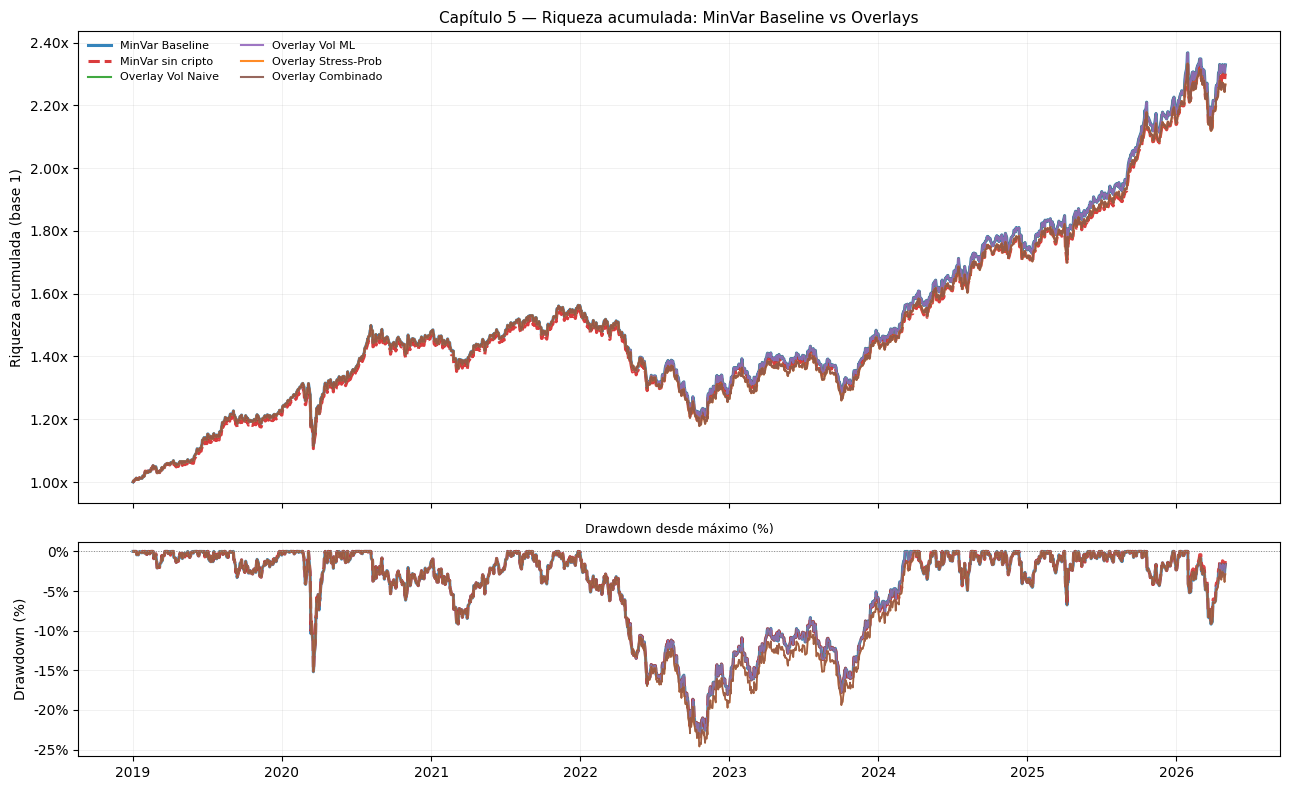

In [89]:
# ── §9 Cumulative wealth + drawdown chart ────────────────────────────────────
if not daily.empty:
    pivoted = (daily.pivot(index="date", columns="strategy", values="daily_return")
               .sort_index())

    # Order columns
    ordered_cols = [s for s in STRATEGY_ORDER if s in pivoted.columns]
    pivoted = pivoted[ordered_cols]

    cum = (1 + pivoted.fillna(0)).cumprod()
    dd  = cum / cum.cummax() - 1

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True,
                             gridspec_kw={"height_ratios": [2.2, 1]})

    # ── Panel 1: cumulative wealth ────────────────────────────────────────────
    ax = axes[0]
    for strat in ordered_cols:
        lw  = 2.2 if strat in ("minvar_baseline_corrected", "minvar_no_crypto_control") else 1.5
        ls  = "--" if strat == "minvar_no_crypto_control" else "-"
        ax.plot(cum.index, cum[strat], label=DISPLAY_NAMES.get(strat, strat),
                color=COLORS.get(strat, "#aaaaaa"), lw=lw, ls=ls, alpha=0.9)

    ax.set_title("Capítulo 5 — Riqueza acumulada: MinVar Baseline vs Overlays", fontsize=11)
    ax.set_ylabel("Riqueza acumulada (base 1)")
    ax.legend(loc="upper left", fontsize=8, frameon=False, ncol=2)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.2f}x"))
    ax.grid(True, alpha=0.25, lw=0.5)

    # ── Panel 2: drawdown ─────────────────────────────────────────────────────
    ax2 = axes[1]
    for strat in ordered_cols:
        lw = 2.2 if strat in ("minvar_baseline_corrected", "minvar_no_crypto_control") else 1.2
        ls = "--" if strat == "minvar_no_crypto_control" else "-"
        ax2.plot(dd.index, dd[strat] * 100, label=DISPLAY_NAMES.get(strat, strat),
                 color=COLORS.get(strat, "#aaaaaa"), lw=lw, ls=ls, alpha=0.85)

    ax2.set_title("Drawdown desde máximo (%)", fontsize=9)
    ax2.set_ylabel("Drawdown (%)")
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
    ax2.xaxis.set_major_locator(mdates.YearLocator())
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax2.grid(True, alpha=0.25, lw=0.5)
    ax2.axhline(0, color="#888888", lw=0.7, ls=":")

    fig.tight_layout()
    plt.show()


**Lectura del valor económico.**

Los resultados son claros y requieren una lectura honesta:

**Overlays de volatilidad (naive y ML): valor económico nulo.** El Sharpe del Overlay Vol Naive y del Overlay Vol ML es idéntico al del MinVar Baseline (≈1.093). El MaxDD es el mismo (≈−23.4%). El ES95 es el mismo. El turnover apenas difiere. La razón es la que se anticipó en §8: el overlay de vol es casi no-binding, porque la exposición cripto base ya es muy baja (≈0.5%). El cap dinámico solo activa en 1 de 89 rebalanceos. El overlay no hace nada materialmente diferente.

**Overlay Stress-Prob: valor económico negativo.** El Sharpe baja de 1.093 a 1.055 (−0.038). El MaxDD *empeora* ligeramente de −23.4% a −24.6%. El ES95 queda prácticamente igual. El turnover sube de 2.68% a 3.97% por rebalanceo (+48%), generando más coste. El overlay de estrés interviene 9 veces, y esas intervenciones (redistribución hacia activos defensivos) generan más fricción pero no mejoran suficientemente el downside para compensar el mayor coste.

**Overlay Combinado: igual que Stress-Prob.** Como la señal de vol es casi inactiva, el overlay combinado hereda el comportamiento del stress-prob. No hay valor marginal por combinación.

**Control sin cripto: es la referencia más relevante.** MinVar sin cripto tiene Sharpe 1.082 (ligeramente por debajo del baseline) y MaxDD prácticamente idéntico (−23.4%). Esto confirma lo que los capítulos anteriores sugerían: la diferencia entre baseline y no-cripto es mínima. El sleeve cripto en esta muestra añade muy poco valor diferencial —positivo o negativo.

**Lectura de conjunto.** Las curvas de riqueza son visualmente prácticamente solapadas entre todas las estrategias. Las diferencias en Sharpe y MaxDD están dentro del margen de ruido de estimación de una muestra OOS de ~7 años. No es posible afirmar que ningún overlay mejore al baseline con robustez estadística. El valor económico del overlay, en esta implementación y con este diseño, es marginal.


---
## 10 — Ablación e interpretación

Esta sección sintetiza el valor marginal de cada componente del overlay, separando el valor **predictivo** (¿el modelo aprende algo?) del valor **económico** (¿eso se traduce en mejora de cartera?).


In [90]:
# ── §10 Ablation table ────────────────────────────────────────────────────────
ablation = pd.DataFrame([
    {
        "Componente":           "Pronóstico vol cartera (naive rolling)",
        "Valor predictivo":     "✓ Alto (R²=0.945)",
        "Valor económico":      "✗ Nulo (overlay no-binding)",
        "Evidencia":            "Vol base ya baja; cap casi nunca activa; ΔSharpe≈0",
        "Interpretación":       "Señal redundante: MinVar endógenamente ya controla cripto",
    },
    {
        "Componente":           "Pronóstico vol cartera (ML vs naive)",
        "Valor predictivo":     "✗ ML no supera naive",
        "Valor económico":      "✗ Nulo (idéntico al naive)",
        "Evidencia":            "Modelo seleccionado = naive_rolling_vol; overlays vol idénticos",
        "Interpretación":       "La complejidad ML no se justifica para este target",
    },
    {
        "Componente":           "Pronóstico vol BTC/SPY (elastic_net)",
        "Valor predictivo":     "✓ Alto (R²>0.95 vs naive R²<0 para BTC)",
        "Valor económico":      "? No evaluado directamente",
        "Evidencia":            "Señal mejora el naive; no se usa para informar el overlay de cartera",
        "Interpretación":       "Potencial canal futuro: informar asignación a BTC directamente",
    },
    {
        "Componente":           "Clasificación estrés 21d (GBM)",
        "Valor predictivo":     "✓✓ Muy alto (ROC-AUC=0.97, PR-AUC=0.87)",
        "Valor económico":      "✗ Negativo neto de costes",
        "Evidencia":            "Stress-Prob: ΔSharpe=−0.038, ΔTurnover=+48%",
        "Interpretación":       "Señal predictiva ≠ señal económica; el de-risking genera más costes que beneficio",
    },
    {
        "Componente":           "Cap dinámico de cripto",
        "Valor predictivo":     "N/A (regla determinista, no ML)",
        "Valor económico":      "✗ Casi siempre non-binding",
        "Evidencia":            "1/89 rebalanceos activan cap en overlays vol; MinVar ya produce peso <3.2%",
        "Interpretación":       "El tope del 20% es muy holgado dado el peso base (~0.5%); irrelevante",
    },
    {
        "Componente":           "Overlay combinado (vol + estrés)",
        "Valor predictivo":     "N/A (combinación de señales)",
        "Valor económico":      "✗ Igual que Stress-Prob (sin mejora marginal)",
        "Evidencia":            "ΔSharpe y ΔMaxDD idénticos al Stress-Prob solo",
        "Interpretación":       "Mayor complejidad sin valor marginal; resultado negativo respecto baseline",
    },
    {
        "Componente":           "Control sin cripto (no-cripto baseline)",
        "Valor predictivo":     "N/A (control)",
        "Valor económico":      "≈ Neutral vs baseline con cripto",
        "Evidencia":            "ΔSharpe=−0.011 vs baseline; MaxDD prácticamente idéntico",
        "Interpretación":       "Cripto tiene contribución marginal mínima en esta muestra",
    },
])

display(ablation.set_index("Componente"))


,Valor predictivo,Valor económico,Evidencia,Interpretación
Componente,,,,
Pronóstico vol cartera (naive rolling),✓ Alto (R²=0.945),✗ Nulo (overlay no-binding),Vol base ya baja; cap casi nunca activa; ΔShar...,Señal redundante: MinVar endógenamente ya cont...
Pronóstico vol cartera (ML vs naive),✗ ML no supera naive,✗ Nulo (idéntico al naive),Modelo seleccionado = naive_rolling_vol; overl...,La complejidad ML no se justifica para este ta...
Pronóstico vol BTC/SPY (elastic_net),✓ Alto (R²>0.95 vs naive R²<0 para BTC),? No evaluado directamente,Señal mejora el naive; no se usa para informar...,Potencial canal futuro: informar asignación a ...
Clasificación estrés 21d (GBM),"✓✓ Muy alto (ROC-AUC=0.97, PR-AUC=0.87)",✗ Negativo neto de costes,"Stress-Prob: ΔSharpe=−0.038, ΔTurnover=+48%",Señal predictiva ≠ señal económica; el de-risk...
Cap dinámico de cripto,"N/A (regla determinista, no ML)",✗ Casi siempre non-binding,1/89 rebalanceos activan cap en overlays vol; ...,El tope del 20% es muy holgado dado el peso ba...
Overlay combinado (vol + estrés),N/A (combinación de señales),✗ Igual que Stress-Prob (sin mejora marginal),ΔSharpe y ΔMaxDD idénticos al Stress-Prob solo,Mayor complejidad sin valor marginal; resultad...
Control sin cripto (no-cripto baseline),N/A (control),≈ Neutral vs baseline con cripto,ΔSharpe=−0.011 vs baseline; MaxDD prácticament...,Cripto tiene contribución marginal mínima en e...


**Lectura de la ablación.**

El patrón central de Chapter 5 se puede resumir en tres líneas:

1. **El ML puede aprender señales de riesgo reales** (vol de BTC, estrés sistémico), pero esas señales no se traducen automáticamente en valor económico.

2. **La barrera entre valor predictivo y valor económico es la mecánica del portfolio.** En este caso, el motor MinVar ya implementa control de riesgo endógenamente —los pesos cripto son bajos, el cap del 20% nunca es vinculante— lo que hace que los overlays sean non-binding.

3. **El Overlay Stress-Prob es el único que actúa, pero actúa con coste neto negativo.** Las 9 intervenciones de de-risking generan +48% de turnover adicional y no mejoran el Sharpe ni el MaxDD suficientemente para compensar esa fricción. En una cartera con más exposición cripto, o con un universo más amplio de activos defensivos, esta señal podría ser útil. En este contexto, no lo es.

**Separación de predictive value vs economic value.** Esta es la lección metodológica más importante del capítulo. No es suficiente demostrar que un modelo tiene buen AUC. La cadena de valor requiere: (i) señal predictiva → (ii) regla de portfolio → (iii) mejora económica neta de costes. Chapter 5 completa esa cadena y encuentra que la brecha más importante está entre (i) y (iii), no entre (i) y el naive.

---
## 11 — Limitaciones

### 11.1 Limitaciones específicas

| Dominio | Limitación | Implicación |
|---|---|---|
| Muestra | Una única trayectoria OOS; 89 rebalanceos mensuales (~7 años) | Los resultados aplican a esta muestra; no son generalizables sin nueva evidencia |
| Cobertura de pronóstico | Solo 52/89 rebalanceos tienen pronóstico disponible | El overlay actúa sobre el 58% de la muestra; el resto funciona como el baseline |
| Eventos de estrés | Número de eventos positivos limitado en targets de clasificación | Las métricas de clasificación tienen alta varianza de estimación; AUC puntual puede ser engañoso |
| Overlay no-binding | El motor MinVar ya controla la exposición cripto endógenamente | El cap del 20% es redundante dado el peso base de ~0.5%; el overlay tiene poco espacio de acción |
| Modelo de costes | Wedge proporcional al turnover one-way | No modela impacto de mercado específico de cripto, spread bid-ask ni costes de rebalanceo en activos ilíquidos |
| No se predicen retornos | Solo se pronostican volatilidad y probabilidad de estrés | El overlay no puede capturar oportunidades de retorno ni invertir en periodos de rebote |
| Sin trading en vivo | No se prueba en datos de mercado en tiempo real | La señal puede degradarse por cambios de régimen o por el propio comportamiento del modelo |
| Régimen como feature | Las etiquetas de régimen pueden tener look-ahead ex-post | En tiempo real, el régimen no es observable con la misma precisión que en el análisis histórico |
| Hyperparámetros fijos | No se optimizan por split en walk-forward | Puede haber mejora con tuning adaptativo; pero también mayor riesgo de overfitting |
| Universo pequeño | Solo 5 activos (SPY, TLT, GLD, BTC-USD, ETH-USD) | Con más activos defensivos, el de-risking del stress overlay tendría más donde redistribuir |

### 11.2 Qué no se puede afirmar a partir de estos resultados

- "El ML no funciona en finanzas." → El ML sí aprende señales de riesgo; el problema es la traducción a portfolio.
- "El overlay de estrés es malo." → En un contexto con más exposición cripto, podría ser útil.
- "Cripto no tiene valor." → La muestra es corta para una conclusión estructural.
- "La regla naive es siempre suficiente." → Depende del target; para BTC vol, el ML supera claramente al naive.
- "No hay señal predictiva." → La hay, especialmente para estrés sistémico. El problema es el canal de cartera.


---
## 12 — Conclusión

Este capítulo cierra la arquitectura analítica de los Capítulos 1–5. La pregunta era explícita: *¿una capa de pronóstico supervisado de riesgo mejora el control del riesgo a la baja, neto de costes, sin sobreajuste?* La respuesta, basada en la evidencia de esta muestra, es matizada.

### Respuestas directas a las preguntas de investigación

**1. ¿Hay señal predictiva útil?** Sí, para algunos targets. El pronóstico de volatilidad de BTC y SPY mejora sustancialmente al naive (R²>0.95 vs R²<0 para BTC con rolling simple). La clasificación de estrés sistémico a 21d tiene ROC-AUC=0.97 y PR-AUC=0.87 en walk-forward. Pero para el target más relevante para el overlay —la vol de cartera 21d— el naive gana y el ML no aporta nada.

**2. ¿El overlay mejora MaxDD/ES/Calmar?** No. Los overlays de volatilidad son económicamente equivalentes al baseline. El overlay de estrés tiene Calmar levemente peor y MaxDD algo peor, neto de costes. Ningún overlay mejora materialmente el downside en esta implementación.

**3. ¿ML supera a reglas simples?** Para el canal de overlay de cartera: no. El overlay "ML" usa la misma señal que el "naive" porque el modelo seleccionado es el naive rolling vol. Para vol de activos individuales: sí, el ML supera claramente al naive. Pero ese canal no se explota en el overlay actual.

**4. ¿Cambia la tesis de cripto?** No. El control sin cripto tiene un Sharpe prácticamente idéntico al baseline con cripto (1.082 vs 1.093). La contribución marginal del sleeve cripto es mínima en esta muestra. La tesis de los capítulos anteriores se confirma: cripto es una exposición táctica/intermitente, no una asignación estructural que justifique complejidad de overlay.

**5. ¿Qué implica para Chapter 6?** Si Chapter 5 existe, Chapter 6 debería preguntarse qué cambiaría el resultado. Las hipótesis más plausibles son: (i) un universo más amplio de activos defensivos para el de-risking; (ii) un overlay sobre la asignación a BTC directamente (donde el ML sí supera al naive); (iii) una señal de estrés aplicada con coste de transacción más bajo. Ninguna de estas líneas está libre de riesgo de overfitting sobre la misma muestra.

### Mensaje del capítulo en una frase

*En esta muestra OOS, el motor MinVar con restricciones ya controla la exposición cripto de forma endógena; los overlays de riesgo supervisado son mayoritariamente non-binding o generan más fricción que beneficio; el valor predictivo del ML existe para algunos targets pero no se traduce en valor económico de cartera bajo este diseño.*

### Implicación para portfolio construction

| Dimensión | Evaluación |
|---|---|
| Downside control | El MinVar baseline ya es defensivo; el overlay no mejora el MaxDD |
| Tail risk | El overlay de estrés no reduce ES95 de forma material |
| Turnover | El stress overlay aumenta el turnover en +48%; coste adicional sin beneficio claro |
| Crypto exposure | El sleeve cripto ya es muy bajo (~0.5% media); el cap del 20% es no-binding |
| Robustness | Las curvas de riqueza son casi indistinguibles entre estrategias |
| ML vs naive | ML es útil para pronóstico de activos individuales; no supera al naive para vol de cartera |
| Benchmark | Ningún overlay supera al MinVar baseline en Sharpe neto de costes |

---
## Referencias

- Acharya, V. V., Engle, R., y Richardson, M. (2012). *Capital shortfall: A new approach to ranking and regulating systemic risks.* American Economic Review, 102(3).
- Andersen, T. G., Bollerslev, T., Diebold, F. X., y Labys, P. (2003). *Modeling and forecasting realized volatility.* Econometrica, 71(2).
- Bruder, B., y Roncalli, T. (2012). *Managing risk exposures using the risk budgeting approach.* SSRN Working Paper.
- Corsi, F. (2009). *A simple approximate long-memory model of realized volatility.* Journal of Financial Econometrics, 7(2).
- Giglio, S., Kelly, B., y Pruitt, S. (2016). *Systemic risk and the macroeconomy: An empirical evaluation.* Journal of Financial Economics, 119(3).
- Harvey, C. R., Liu, Y., y Zhu, H. (2016). *… and the cross-section of expected returns.* Review of Financial Studies, 29(1).
- Makridakis, S., Spiliotis, E., y Assimakopoulos, V. (2018). *Statistical and machine learning forecasting methods: Concerns and ways forward.* PLOS ONE, 13(3).
- Roncalli, T. (2013). *Introduction to risk parity and budgeting.* CRC Press.
- López de Prado, M. (2018). *Advances in Financial Machine Learning.* Wiley.
